# 02.3 — K-means + Particle Swarm Optimization (K-means-PSO)

**Algoritma:** K-means dengan Particle Swarm Optimization (PSO)  
**Tujuan:** Metaheuristik populer berbasis swarm sebagai pembanding performa QLDE

| Parameter | Nilai |
|-----------|-------|
| K (cluster) | 6 |
| pop_size | 30 |
| max_iter | 100 |
| w (inertia) | Linear decreasing (0.9 -> 0.4) |
| c1, c2 | 2.0, 2.0 (cognitive, social) |
| Init | Logistic Chaotic (μ=3.9) |

**Output:** `data/Labeled/hasildata_kmeans-pso.csv`


In [1]:
# ============================================================
# Import
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

RANDOM_SEED = 42
K_OPTIMAL   = 6
ALGO_NAME   = 'kmeans-pso'
np.random.seed(RANDOM_SEED)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
CLUSTER_COLORS = ['#E63946','#2A9D8F','#E9C46A','#264653','#F4A261','#A8DADC']
print(f'Algoritma: K-means-PSO | K={K_OPTIMAL}')

Algoritma: K-means-PSO | K=6


In [2]:
# ============================================================
# Load Data
# ============================================================
df_pca    = pd.read_csv('../data/processed/customer_features_pca.csv', index_col='CustomerID')
df_scaled = pd.read_csv('../data/processed/customer_features_scaled.csv', index_col='CustomerID')
df_raw    = pd.read_csv('../data/processed/customer_features_raw.csv', index_col='CustomerID')

X_pca = df_pca.values
print(f'Data: {X_pca.shape} | {len(df_pca):,} pelanggan, 6 PC')

Data: (4335, 6) | 4,335 pelanggan, 6 PC


## 1. Definisi Kelas KMeans-PSO

In [3]:
# ============================================================
# Kelas KMeansPSO
# ============================================================
class KMeansPSO:
    def __init__(self, n_clusters=6, pop_size=30, max_iter=100,
                 w_max=0.9, w_min=0.4, c1=2.0, c2=2.0, mu=3.9, random_state=None):
        self.n_clusters   = n_clusters
        self.pop_size     = pop_size
        self.max_iter     = max_iter
        self.w_max        = w_max
        self.w_min        = w_min
        self.c1           = c1
        self.c2           = c2
        self.mu           = mu
        self.random_state = random_state

    def _logistic_chaotic(self, n_pop, dim):
        if self.random_state is not None:
            np.random.seed(self.random_state)
        phi_0  = np.random.rand(dim)
        pop    = np.zeros((n_pop, dim))
        pop[0] = phi_0
        for i in range(1, n_pop):
            phi    = pop[i-1]
            pop[i] = self.mu * phi * (1 - phi)
        return pop

    def _fitness(self, centers, X):
        cr = centers.reshape(self.n_clusters, -1)
        d  = np.linalg.norm(X[:,np.newaxis,:] - cr[np.newaxis,:,:], axis=2)
        lb = np.argmin(d, axis=1)
        sse = 0.0
        for l in range(self.n_clusters):
            mask = lb == l
            if mask.sum() > 0:
                sse += np.sum((X[mask] - X[mask].mean(axis=0))**2)
        return sse

    def fit(self, X):
        n, d   = X.shape
        dim    = self.n_clusters * d
        LB     = np.tile(X.min(axis=0), self.n_clusters)
        UB     = np.tile(X.max(axis=0), self.n_clusters)
        
        # Inisialisasi posisi dan kecepatan
        pop    = LB + self._logistic_chaotic(self.pop_size, dim) * (UB - LB)
        vel    = np.zeros_like(pop)
        
        pbest_pos = pop.copy()
        pbest_fit = np.array([self._fitness(p, X) for p in pop])
        
        gbest_idx = np.argmin(pbest_fit)
        gbest_pos = pbest_pos[gbest_idx].copy()
        gbest_fit = pbest_fit[gbest_idx]
        
        self.convergence_curve_ = [gbest_fit]

        for k in range(1, self.max_iter + 1):
            w = self.w_max - k * ((self.w_max - self.w_min) / self.max_iter)
            
            for i in range(self.pop_size):
                r1 = np.random.rand(dim)
                r2 = np.random.rand(dim)
                
                vel[i] = (w * vel[i] + 
                          self.c1 * r1 * (pbest_pos[i] - pop[i]) + 
                          self.c2 * r2 * (gbest_pos - pop[i]))
                
                pop[i] = pop[i] + vel[i]
                pop[i] = np.clip(pop[i], LB, UB)
                
                fit_i = self._fitness(pop[i], X)
                
                if fit_i < pbest_fit[i]:
                    pbest_fit[i] = fit_i
                    pbest_pos[i] = pop[i].copy()
                    
                    if fit_i < gbest_fit:
                        gbest_fit = fit_i
                        gbest_pos = pop[i].copy()
                        
            self.convergence_curve_.append(gbest_fit)

        init_c = gbest_pos.reshape(self.n_clusters, d)
        km = KMeans(n_clusters=self.n_clusters, init=init_c, n_init=1,
                    max_iter=300, random_state=self.random_state)
        km.fit(X)
        self.labels_          = km.labels_
        self.cluster_centers_ = km.cluster_centers_
        self.inertia_         = km.inertia_
        self.best_pso_sse_    = gbest_fit
        return self

print('Kelas KMeansPSO berhasil didefinisikan.')

Kelas KMeansPSO berhasil didefinisikan.


## 2. Jalankan Algoritma

In [4]:
# ============================================================
# Jalankan K-means-PSO
# ============================================================
t_start = time.time()

model = KMeansPSO(
    n_clusters   = K_OPTIMAL,
    pop_size     = 30,
    max_iter     = 100,
    random_state = RANDOM_SEED
)
model.fit(X_pca)

t_elapsed = time.time() - t_start
labels    = model.labels_

# Metrik
sse = model.inertia_
sil = silhouette_score(X_pca, labels)
db  = davies_bouldin_score(X_pca, labels)
ch  = calinski_harabasz_score(X_pca, labels)

print(f'✓ Selesai dalam {t_elapsed:.2f} detik')
print(f'  SSE PSO (evolusi)    : {model.best_pso_sse_:,.2f}')
print(f'  SSE K-means final    : {sse:,.2f}')
print(f'  Silhouette Score     : {sil:.4f}')
print(f'  Davies-Bouldin Index : {db:.4f}')
print(f'  Calinski-Harabasz    : {ch:.2f}')


✓ Selesai dalam 5.84 detik
  SSE PSO (evolusi)    : 17,940.31
  SSE K-means final    : 17,699.76
  Silhouette Score     : 0.3542
  Davies-Bouldin Index : 0.9527
  Calinski-Harabasz    : 1276.08


## 3. Visualisasi

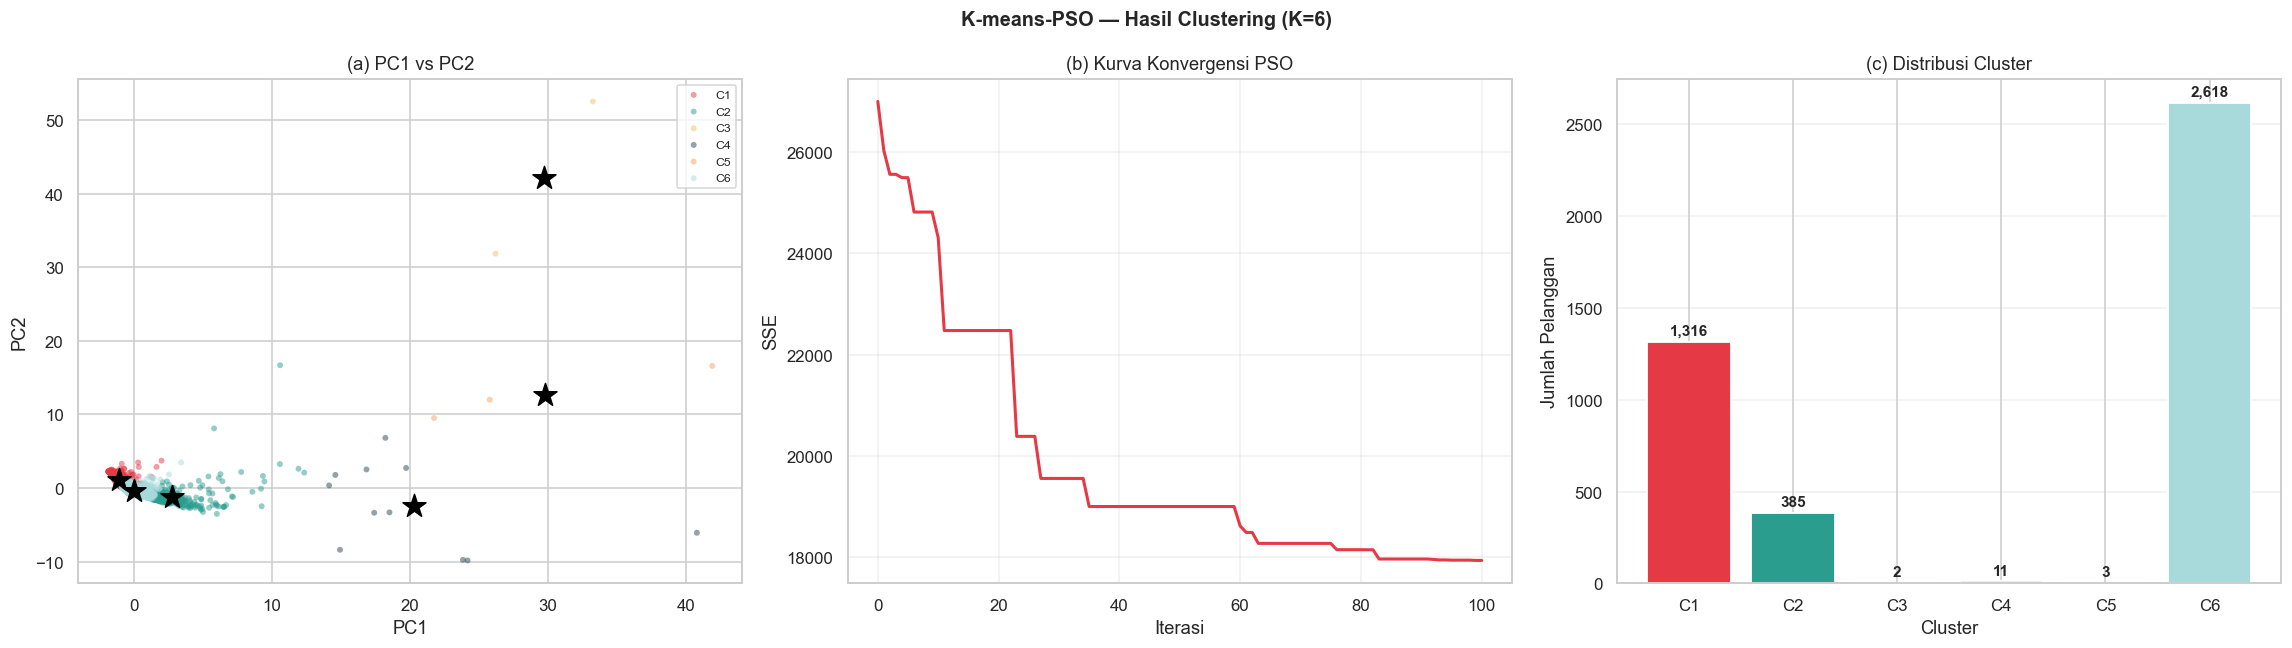

✓ Plot disimpan → models/result_kmeans-pso.png


In [5]:
# ============================================================
# Visualisasi: Scatter + Kurva Konvergensi
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle(f'K-means-PSO — Hasil Clustering (K={K_OPTIMAL})', fontsize=13, fontweight='bold')

# Panel 1: Scatter PC1 vs PC2
ax1 = axes[0]
for c in range(K_OPTIMAL):
    mask = labels == c
    ax1.scatter(X_pca[mask,0], X_pca[mask,1], c=CLUSTER_COLORS[c],
                label=f'C{c+1}', s=15, alpha=0.5, edgecolors='none')
ax1.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1],
            c='black', marker='*', s=250, zorder=10)
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')
ax1.set_title('(a) PC1 vs PC2')
ax1.legend(fontsize=8)

# Panel 2: Kurva konvergensi
ax2 = axes[1]
ax2.plot(model.convergence_curve_, color='#E63946', linewidth=2)
ax2.set_xlabel('Iterasi'); ax2.set_ylabel('SSE')
ax2.set_title('(b) Kurva Konvergensi PSO')
ax2.grid(True, alpha=0.3)

# Panel 3: Distribusi cluster
ax3 = axes[2]
counts = [(labels == c).sum() for c in range(K_OPTIMAL)]
bars = ax3.bar([f'C{c+1}' for c in range(K_OPTIMAL)], counts,
               color=CLUSTER_COLORS, edgecolor='white', linewidth=1.2)
for bar, cnt in zip(bars, counts):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{cnt:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_xlabel('Cluster'); ax3.set_ylabel('Jumlah Pelanggan')
ax3.set_title('(c) Distribusi Cluster')
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'../models/result_{ALGO_NAME}.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'✓ Plot disimpan → models/result_{ALGO_NAME}.png')

## 4. Simpan Hasil

In [6]:
# ============================================================
# Simpan Hasil Clustering
# ============================================================
import os
os.makedirs('../data/Labeled', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# Dataset berlabel
df_labeled = df_raw.copy()
df_labeled['Cluster_kmeans_pso'] = labels
df_labeled.to_csv('../data/Labeled/hasildata_kmeans-pso.csv')

print('File berhasil disimpan: ../data/Labeled/hasildata_kmeans-pso.csv')


File berhasil disimpan: ../data/Labeled/hasildata_kmeans-pso.csv


## 2. Visualisasi Hasil Clustering

### 5.1 Kurva Konvergensi K-means-PSO

Menampilkan bagaimana SSE berkurang seiring iterasi K-means-PSO berjalan.

In [7]:
# ============================================================
# Setup labels for visualization
# ============================================================
df_pca['Cluster'] = labels
df_scaled['Cluster'] = labels
df_raw['Cluster'] = labels


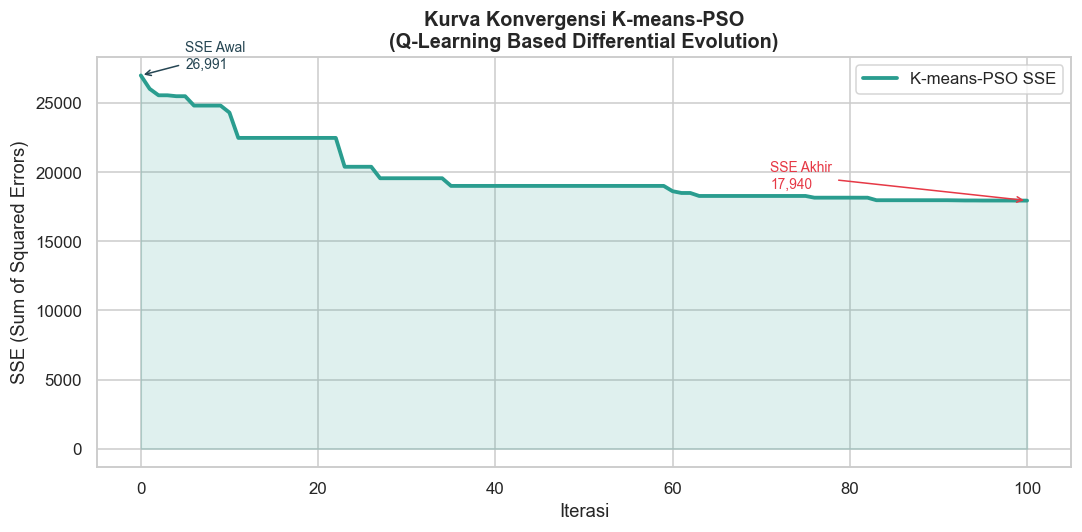

Perbaikan SSE: 33.53%


In [8]:
# ============================================================
# Visualisasi 1: Kurva Konvergensi K-means-PSO
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(model.convergence_curve_, color='#2A9D8F', linewidth=2.5, label='K-means-PSO SSE')
ax.fill_between(range(len(model.convergence_curve_)),
                model.convergence_curve_, alpha=0.15, color='#2A9D8F')

ax.set_title('Kurva Konvergensi K-means-PSO\n(Q-Learning Based Differential Evolution)', fontsize=13, fontweight='bold')
ax.set_xlabel('Iterasi')
ax.set_ylabel('SSE (Sum of Squared Errors)')
ax.legend(fontsize=11)

# Annotasi SSE awal dan akhir
ax.annotate(f'SSE Awal\n{model.convergence_curve_[0]:,.0f}',
            xy=(0, model.convergence_curve_[0]),
            xytext=(5, model.convergence_curve_[0] * 1.02),
            fontsize=9, color='#264653',
            arrowprops=dict(arrowstyle='->', color='#264653'))
ax.annotate(f'SSE Akhir\n{model.convergence_curve_[-1]:,.0f}',
            xy=(len(model.convergence_curve_)-1, model.convergence_curve_[-1]),
            xytext=(len(model.convergence_curve_)-30, model.convergence_curve_[-1] * 1.05),
            fontsize=9, color='#E63946',
            arrowprops=dict(arrowstyle='->', color='#E63946'))

plt.tight_layout()
plt.savefig('../models/pso_convergence.png', bbox_inches='tight', dpi=150)
plt.show()

improvement = (model.convergence_curve_[0] - model.convergence_curve_[-1]) / model.convergence_curve_[0] * 100
print(f'Perbaikan SSE: {improvement:.2f}%')

### 5.2 Proporsi Pelanggan per Cluster (Fig 10 Paper)

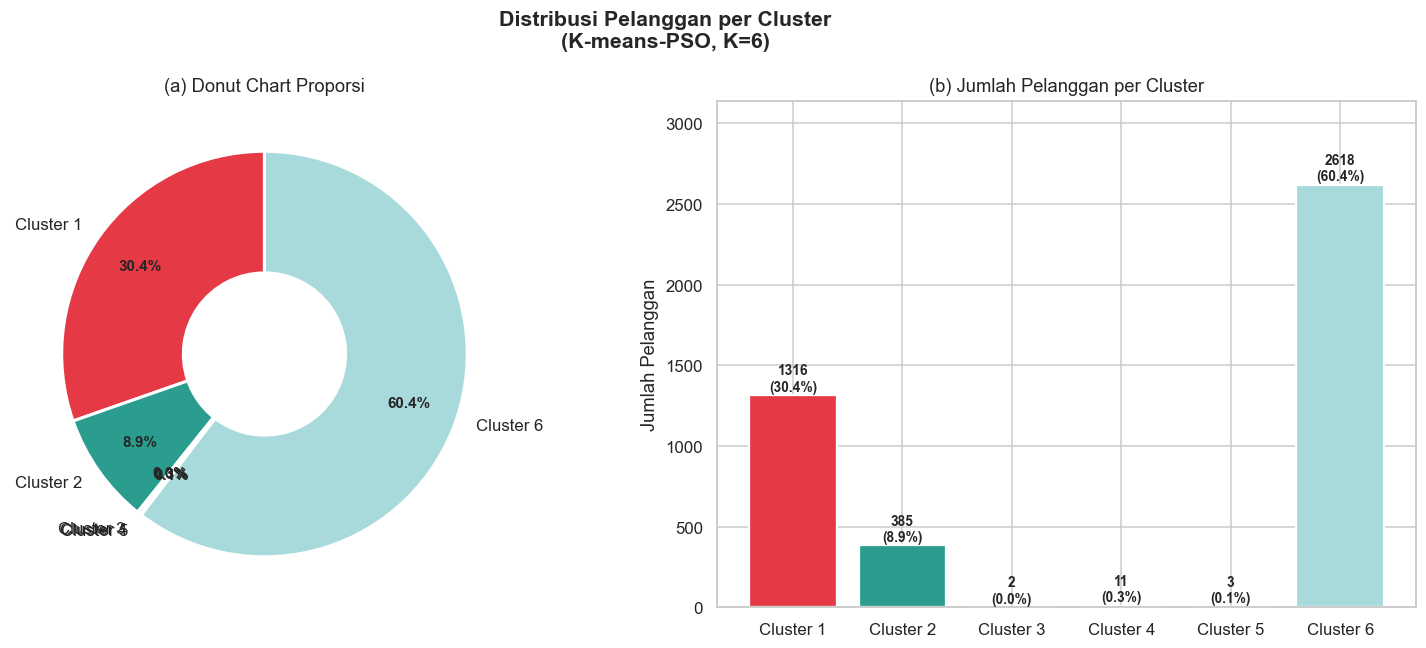

In [9]:
# ============================================================
# Visualisasi 2: Proporsi Pelanggan per Cluster
# Mereplikasi Fig 10 paper
# ============================================================
cluster_counts = pd.Series(model.labels_).value_counts().sort_index()
cluster_pcts   = cluster_counts / cluster_counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribusi Pelanggan per Cluster\n(K-means-PSO, K=6)', fontsize=14, fontweight='bold')

# Pie Chart
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    cluster_counts.values,
    labels=[f'Cluster {c+1}' for c in cluster_counts.index],
    colors=CLUSTER_COLORS,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax.set_title('(a) Donut Chart Proporsi', fontsize=12)

# Bar Chart
ax = axes[1]
bars = ax.bar(
    [f'Cluster {c+1}' for c in cluster_counts.index],
    cluster_counts.values,
    color=CLUSTER_COLORS,
    edgecolor='white', linewidth=1.5
)
for bar, cnt, pct in zip(bars, cluster_counts.values, cluster_pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{cnt}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('(b) Jumlah Pelanggan per Cluster', fontsize=12)
ax.set_ylabel('Jumlah Pelanggan')
ax.set_ylim(0, cluster_counts.max() * 1.2)

plt.tight_layout()
plt.savefig('../models/cluster_distribution_pso.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.3 Visualisasi 3D pada 3 PC Pertama (Fig 11 Paper)

Paper (Fig 11) memvisualisasikan hasil clustering pada ruang 3 principal component pertama.

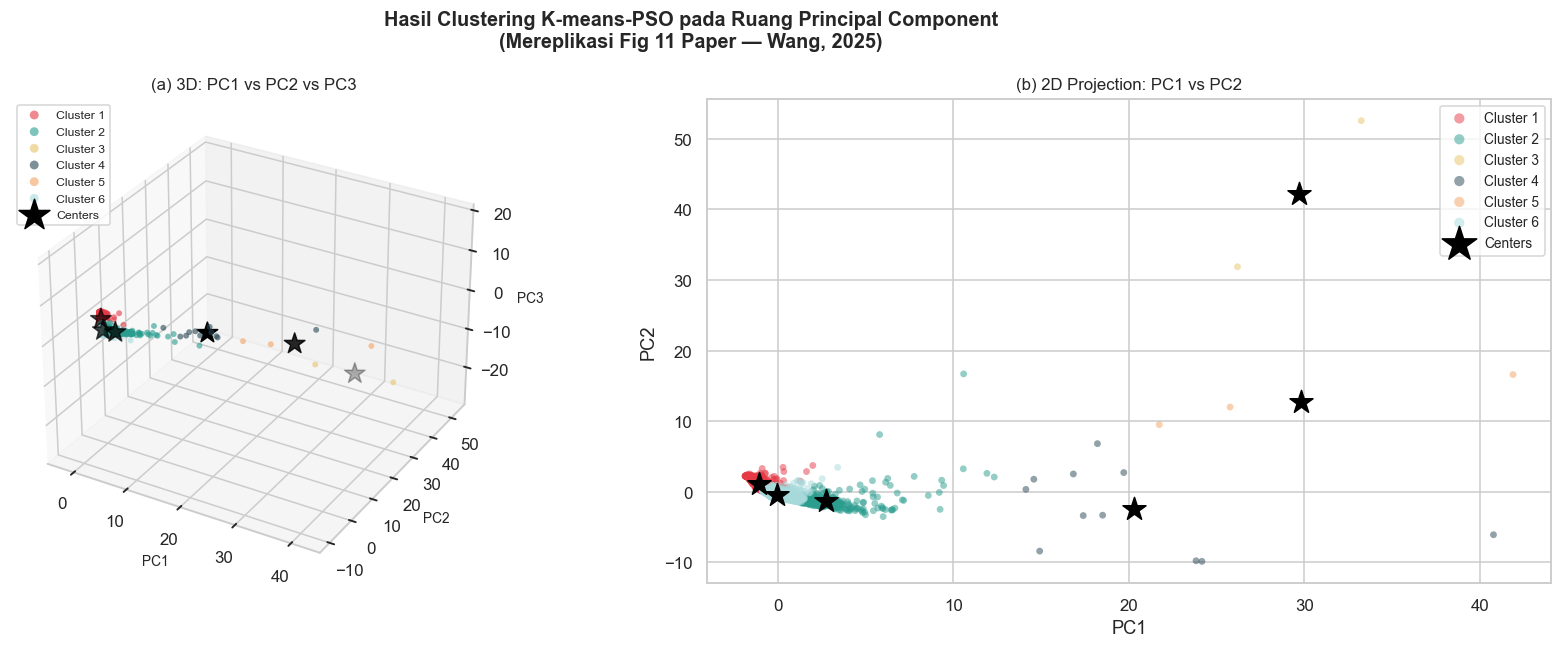

In [10]:
# ============================================================
# Visualisasi 3: Scatter Plot 3D pada PC1, PC2, PC3
# Mereplikasi Fig 11 paper
# ============================================================
labels = model.labels_

fig = plt.figure(figsize=(16, 6))
fig.suptitle('Hasil Clustering K-means-PSO pada Ruang Principal Component\n'
             '(Mereplikasi Fig 11 Paper — Wang, 2025)',
             fontsize=13, fontweight='bold')

# ── Panel 1: 3D scatter PC1 vs PC2 vs PC3 ──
ax1 = fig.add_subplot(121, projection='3d')
for c in range(K_OPTIMAL):
    mask = labels == c
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2],
                c=CLUSTER_COLORS[c], label=f'Cluster {c+1}',
                s=15, alpha=0.6, edgecolors='none')

# Plot cluster centers
centers_2d = model.cluster_centers_
ax1.scatter(centers_2d[:, 0], centers_2d[:, 1], centers_2d[:, 2],
            c='black', marker='*', s=200, zorder=10, label='Centers')

ax1.set_xlabel('PC1', fontsize=9)
ax1.set_ylabel('PC2', fontsize=9)
ax1.set_zlabel('PC3', fontsize=9)
ax1.set_title('(a) 3D: PC1 vs PC2 vs PC3', fontsize=11)
ax1.legend(loc='upper left', fontsize=8, markerscale=1.5)

# ── Panel 2: 2D scatter PC1 vs PC2 ──
ax2 = fig.add_subplot(122)
for c in range(K_OPTIMAL):
    mask = labels == c
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=CLUSTER_COLORS[c], label=f'Cluster {c+1}',
                s=20, alpha=0.5, edgecolors='none')

ax2.scatter(centers_2d[:, 0], centers_2d[:, 1],
            c='black', marker='*', s=250, zorder=10, label='Centers')

ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('(b) 2D Projection: PC1 vs PC2', fontsize=11)
ax2.legend(fontsize=9, markerscale=1.5)

plt.tight_layout()
plt.savefig('../models/cluster_3d_scatter_pso.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.4 Analisis Cluster Centers — Radar & Bar Chart (Fig 12 Paper)

Paper (Fig 12) menampilkan *ranking* nilai cluster centers di 11 fitur untuk mengidentifikasi karakteristik tiap cluster.

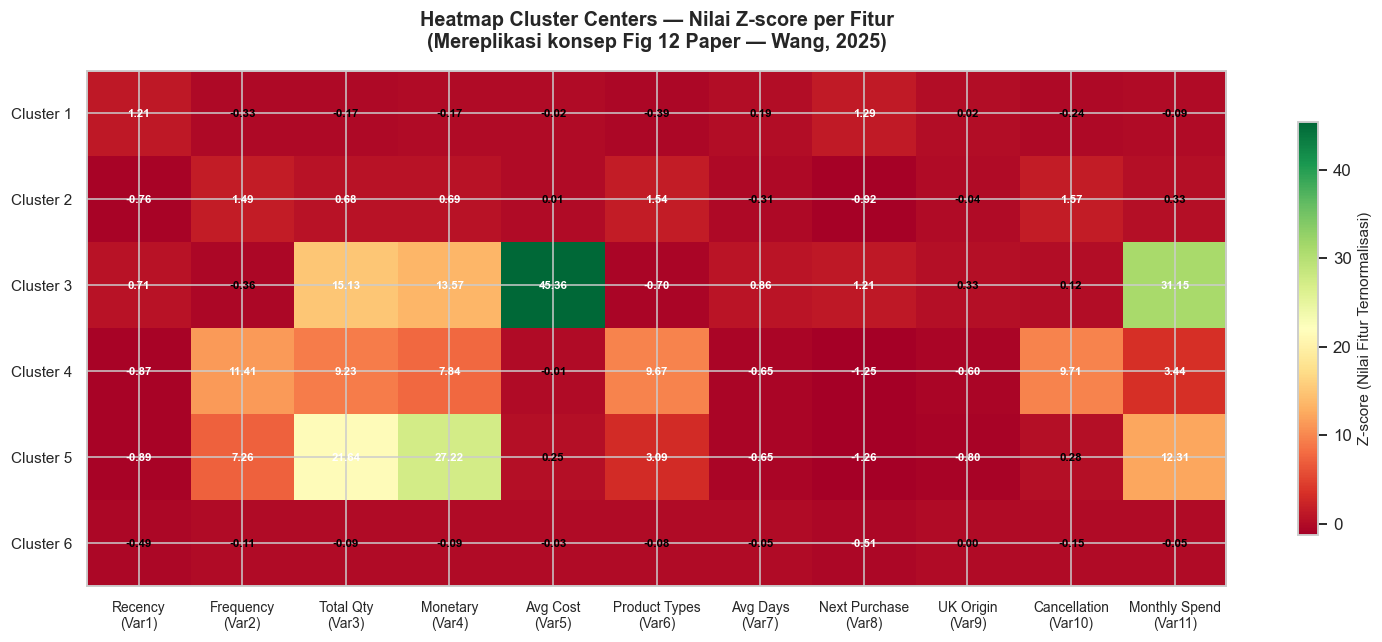


Cluster Centers (Z-score):
            Var1    Var2    Var3    Var4    Var5   Var6   Var7   Var8   Var9  Var10   Var11
Cluster 1  1.209  -0.329  -0.174  -0.166  -0.021 -0.387  0.190  1.289  0.018 -0.237  -0.092
Cluster 2 -0.755   1.486   0.683   0.693   0.010  1.536 -0.307 -0.921 -0.043  1.565   0.327
Cluster 3  0.707  -0.360  15.126  13.565  45.356 -0.697  0.861  1.213  0.327  0.115  31.145
Cluster 4 -0.873  11.410   9.233   7.838  -0.009  9.673 -0.651 -1.245 -0.597  9.712   3.442
Cluster 5 -0.889   7.258  21.639  27.222   0.252  3.086 -0.651 -1.261 -0.803  0.284  12.314
Cluster 6 -0.493  -0.109  -0.088  -0.093  -0.026 -0.075 -0.047 -0.507  0.001 -0.152  -0.054


In [11]:
# ============================================================
# Visualisasi 4: Heatmap Cluster Centers (11 fitur, Z-score)
# Mereplikasi konsep Fig 12 paper
# ============================================================

# Hitung cluster centers pada scaled data (11 fitur)
feature_cols = [f'Var{i}' for i in range(1, 12)]
feature_desc = [
    'Recency\n(Var1)', 'Frequency\n(Var2)', 'Total Qty\n(Var3)',
    'Monetary\n(Var4)', 'Avg Cost\n(Var5)', 'Product Types\n(Var6)',
    'Avg Days\n(Var7)', 'Next Purchase\n(Var8)', 'UK Origin\n(Var9)',
    'Cancellation\n(Var10)', 'Monthly Spend\n(Var11)'
]

# Cluster centers pada fitur Z-score
centers_df = df_scaled.groupby('Cluster')[feature_cols].mean()
centers_df.index = [f'Cluster {i+1}' for i in centers_df.index]

fig, ax = plt.subplots(figsize=(14, 6))

im = ax.imshow(centers_df.values, cmap='RdYlGn', aspect='auto',
               vmin=centers_df.values.min(), vmax=centers_df.values.max())

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Z-score (Nilai Fitur Ternormalisasi)', fontsize=10)

ax.set_xticks(range(len(feature_cols)))
ax.set_xticklabels(feature_desc, fontsize=9)
ax.set_yticks(range(len(centers_df)))
ax.set_yticklabels(centers_df.index, fontsize=10)

# Nilai pada sel
for i in range(len(centers_df)):
    for j in range(len(feature_cols)):
        val = centers_df.values[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7.5, color=color, fontweight='bold')

ax.set_title('Heatmap Cluster Centers — Nilai Z-score per Fitur\n'
             '(Mereplikasi konsep Fig 12 Paper — Wang, 2025)',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../models/cluster_centers_heatmap_pso.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nCluster Centers (Z-score):')
print(centers_df.round(3).to_string())

### 5.5 Radar Chart — Profil 6 Cluster

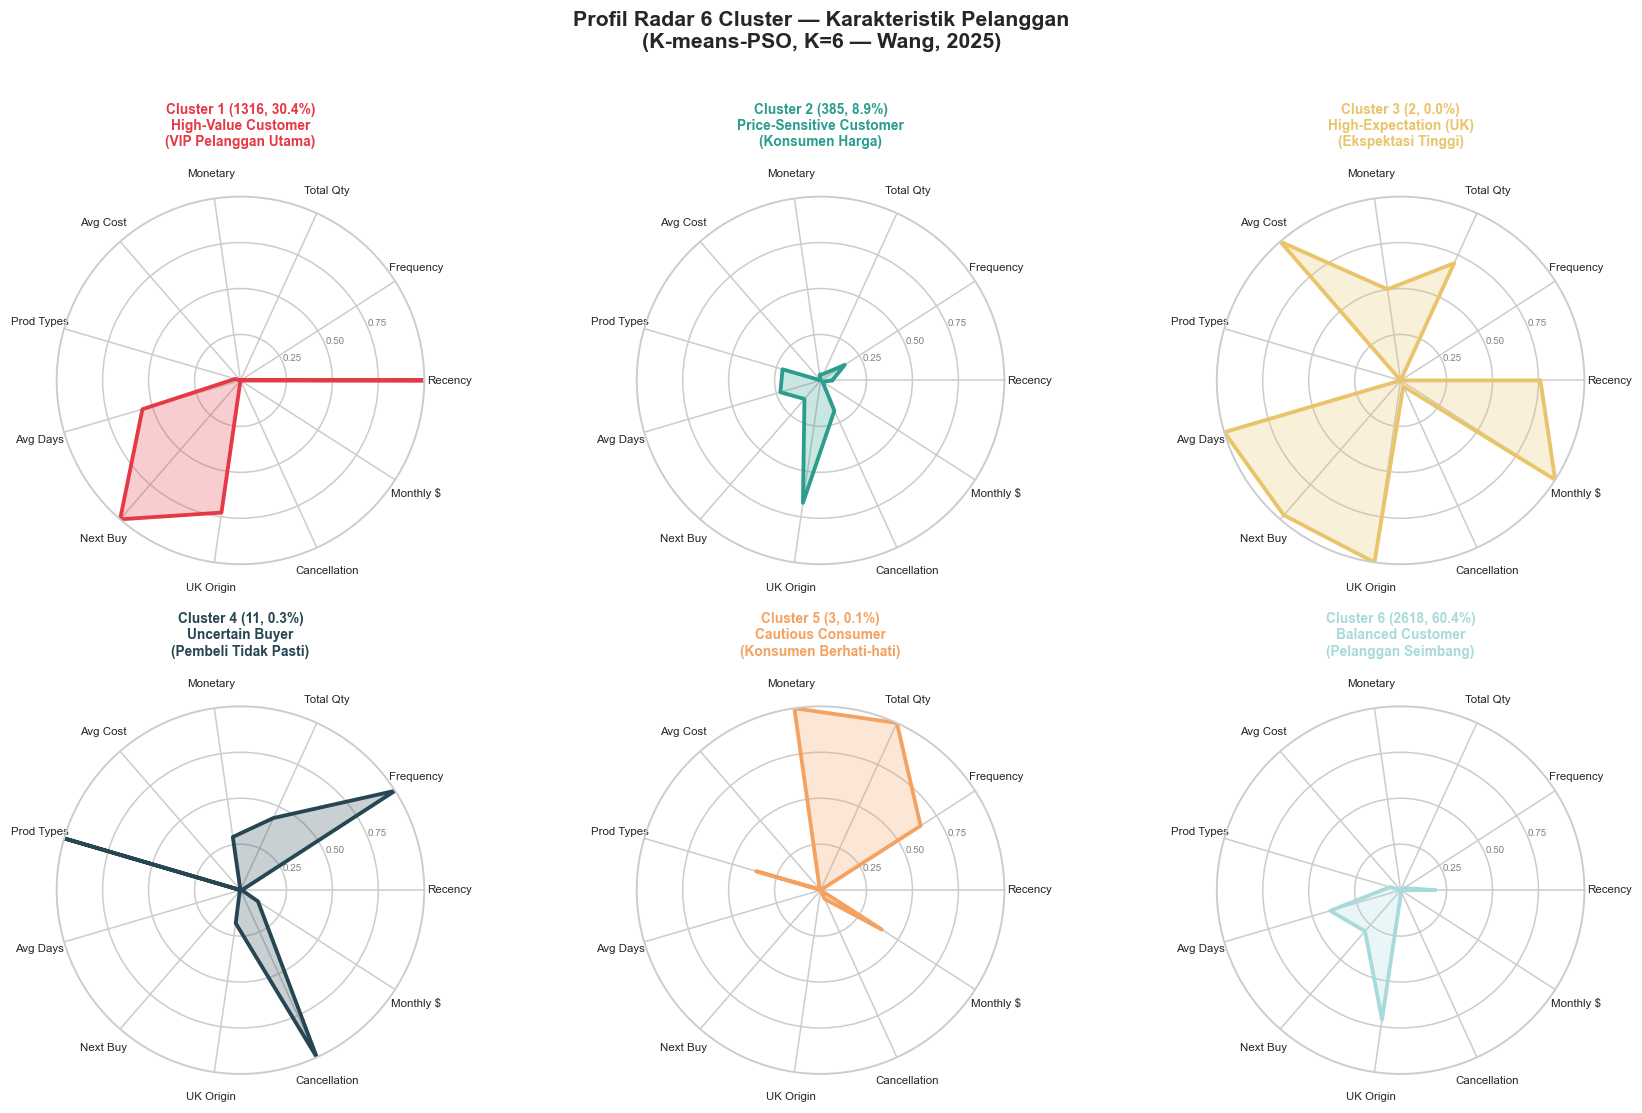

In [12]:
# ============================================================
# Visualisasi 5: Radar Chart (Spider Plot) tiap cluster
# ============================================================

# Gunakan nilai mentah (raw) ternormalisasi ke [0,1] untuk radar
centers_raw = df_raw.groupby('Cluster')[feature_cols].mean()
centers_raw.index = [f'Cluster {i+1}' for i in centers_raw.index]

# Min-max normalize cluster centers untuk tampilan radar
from sklearn.preprocessing import MinMaxScaler
scaler_mm = MinMaxScaler()
centers_norm = pd.DataFrame(
    scaler_mm.fit_transform(centers_raw.values),
    index=centers_raw.index,
    columns=feature_cols
)

# Short labels untuk radar
radar_labels = ['Recency', 'Frequency', 'Total Qty', 'Monetary', 'Avg Cost',
                'Prod Types', 'Avg Days', 'Next Buy', 'UK Origin', 'Cancellation', 'Monthly $']

N = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, axes = plt.subplots(2, 3, figsize=(16, 10), subplot_kw=dict(polar=True))
fig.suptitle('Profil Radar 6 Cluster — Karakteristik Pelanggan\n'
             '(K-means-PSO, K=6 — Wang, 2025)',
             fontsize=14, fontweight='bold', y=1.01)

cluster_profiles = [
    ('Cluster 1', 'High-Value Customer\n(VIP Pelanggan Utama)'),
    ('Cluster 2', 'Price-Sensitive Customer\n(Konsumen Harga)'),
    ('Cluster 3', 'High-Expectation (UK)\n(Ekspektasi Tinggi)'),
    ('Cluster 4', 'Uncertain Buyer\n(Pembeli Tidak Pasti)'),
    ('Cluster 5', 'Cautious Consumer\n(Konsumen Berhati-hati)'),
    ('Cluster 6', 'Balanced Customer\n(Pelanggan Seimbang)'),
]

for ax, (cname, profile), color in zip(axes.flatten(), cluster_profiles, CLUSTER_COLORS):
    values = centers_norm.loc[cname].values.tolist()
    values += values[:1]  # close the loop
    
    ax.plot(angles, values, color=color, linewidth=2.5)
    ax.fill(angles, values, color=color, alpha=0.25)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=7.5)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['0.25', '0.50', '0.75'], fontsize=6.5, color='gray')
    
    cnt = (df_pca['Cluster'] == int(cname.split()[-1]) - 1).sum()
    pct = cnt / len(df_pca) * 100
    ax.set_title(f'{cname} ({cnt}, {pct:.1f}%)\n{profile}',
                 fontsize=9, fontweight='bold', color=color, pad=15)

plt.tight_layout()
plt.savefig('../models/cluster_radar_pso.png', bbox_inches='tight', dpi=150)
plt.show()

## 3. Evaluasi Kualitas Clustering (Metrik)

Mengevaluasi hasil clustering K-means-PSO menggunakan beberapa metrik:

| Metrik | Keterangan | Ideal |
|--------|-----------|-------|
| **SSE / Inertia** | Sum of Squared Errors (Persamaan 2) | Kecil |
| **Silhouette Score** | Kohesi vs. separasi cluster | Mendekati 1 |
| **Davies-Bouldin Index** | Ratio intra-cluster vs inter-cluster distance | Kecil |
| **Calinski-Harabasz Index** | Ratio dispersi antar- vs intra-cluster | Besar |

In [13]:
# ============================================================
# Evaluasi Metrik Clustering
# ============================================================
labels = model.labels_

sse     = model.inertia_
sil     = silhouette_score(X_pca, labels)
db      = davies_bouldin_score(X_pca, labels)
ch      = calinski_harabasz_score(X_pca, labels)

print('=' * 55)
print('  EVALUASI KUALITAS CLUSTERING — K-means-PSO (K=6)')
print('=' * 55)
print(f'  SSE (Inertia)          : {sse:>15,.2f}  ↓ (kecil = baik)')
print(f'  Silhouette Score       : {sil:>15.4f}  ↑ (mendekati 1 = baik)')
print(f'  Davies-Bouldin Index   : {db:>15.4f}  ↓ (kecil = baik)')
print(f'  Calinski-Harabasz Index: {ch:>15.2f}  ↑ (besar = baik)')
print('=' * 55)

# Simpan metrik untuk perbandingan nanti
results_pso = {
    'Algorithm'  : 'K-means-PSO (Paper)',
    'SSE'        : sse,
    'Silhouette' : sil,
    'Davies-Bouldin': db,
    'Calinski-Harabasz': ch,
    'K'          : K_OPTIMAL
}
print('\nHasil disimpan untuk perbandingan dengan algoritma lain.')

  EVALUASI KUALITAS CLUSTERING — K-means-PSO (K=6)
  SSE (Inertia)          :       17,699.76  ↓ (kecil = baik)
  Silhouette Score       :          0.3542  ↑ (mendekati 1 = baik)
  Davies-Bouldin Index   :          0.9527  ↓ (kecil = baik)
  Calinski-Harabasz Index:         1276.08  ↑ (besar = baik)

Hasil disimpan untuk perbandingan dengan algoritma lain.


## 4. Analisis Karakteristik Cluster (Interpretasi Bisnis)

Menganalisis karakteristik tiap cluster berdasarkan nilai rata-rata fitur (sesuai Fig 12 dan Section 4.2 paper).

In [14]:
# ============================================================
# Analisis Karakteristik Cluster
# ============================================================
feature_desc_short = {
    'Var1'  : 'Recency (hari sejak transaksi terakhir)',
    'Var2'  : 'Frequency (jumlah transaksi)',
    'Var3'  : 'Total produk dibeli',
    'Var4'  : 'Monetary (total pengeluaran)',
    'Var5'  : 'Rata-rata biaya per transaksi',
    'Var6'  : 'Jumlah tipe produk',
    'Var7'  : 'Rata-rata hari antar pembelian',
    'Var8'  : 'Perkiraan hari pembelian berikutnya',
    'Var9'  : 'Asal UK (0/1)',
    'Var10' : 'Frekuensi pembatalan',
    'Var11' : 'Rata-rata pengeluaran bulanan',
}

centers_raw_display = df_raw.groupby('Cluster')[feature_cols].mean().round(2)
centers_raw_display.index = [f'Cluster {i+1}' for i in centers_raw_display.index]
centers_raw_display.columns = [f'{v} ({feature_desc_short[v][:25]}...)' if len(feature_desc_short[v]) > 25
                                else f'{v} ({feature_desc_short[v]})'
                                for v in feature_cols]

# Deskripsi cluster sesuai paper Section 4.2
cluster_descriptions = {
    'Cluster 1': '🏆 HIGH-VALUE (VIP) — Pengeluaran bulanan tinggi, produk terbanyak, cancellation rendah.\n'
                 '   → Kelompok terpenting bagi perusahaan (revenue terbesar). Perlu program loyalitas eksklusif.',
    'Cluster 2': '💰 PRICE-SENSITIVE — Volume pembelian tinggi tapi frequency & spending rendah.\n'
                 '   → Konsumen rasional/hemat. Strategi: promo diskon, bundle harga.',
    'Cluster 3': '🇬🇧 HIGH-EXPECTATION (UK) — Mayoritas pelanggan UK, cancellation sedang.\n'
                 '   → Ekspektasi tinggi pada kualitas produk. Strategi: klarifikasi info produk.',
    'Cluster 4': '❓ UNCERTAIN BUYER — Cancellation tinggi, berasal dari non-UK.\n'
                 '   → Tidak pasti dalam keputusan pembelian. Strategi: optimalkan proses pembayaran.',
    'Cluster 5': '🤔 CAUTIOUS CONSUMER — Recency tinggi, frekuensi rendah, berhati-hati.\n'
                 '   → Banyak pertimbangan sebelum beli. Strategi: promosi akhir pekan, ulasan produk.',
    'Cluster 6': '⚖️  BALANCED CUSTOMER — Performa seimbang di semua indikator.\n'
                 '   → Tanpa preferensi ekstrem. Strategi: marketing diversifikasi.',
}

print('=' * 70)
print('  KARAKTERISTIK 6 CLUSTER — K-means-PSO')
print('  Referensi: Section 4.2, Fig 12 — Wang (2025)')
print('=' * 70)

for c_name, desc in cluster_descriptions.items():
    c_idx = int(c_name.split()[-1]) - 1
    cnt   = (df_pca['Cluster'] == c_idx).sum()
    pct   = cnt / len(df_pca) * 100
    print(f'\n{c_name} — {cnt} pelanggan ({pct:.1f}%)')
    print(f'  {desc}')

  KARAKTERISTIK 6 CLUSTER — K-means-PSO
  Referensi: Section 4.2, Fig 12 — Wang (2025)

Cluster 1 — 1316 pelanggan (30.4%)
  🏆 HIGH-VALUE (VIP) — Pengeluaran bulanan tinggi, produk terbanyak, cancellation rendah.
   → Kelompok terpenting bagi perusahaan (revenue terbesar). Perlu program loyalitas eksklusif.

Cluster 2 — 385 pelanggan (8.9%)
  💰 PRICE-SENSITIVE — Volume pembelian tinggi tapi frequency & spending rendah.
   → Konsumen rasional/hemat. Strategi: promo diskon, bundle harga.

Cluster 3 — 2 pelanggan (0.0%)
  🇬🇧 HIGH-EXPECTATION (UK) — Mayoritas pelanggan UK, cancellation sedang.
   → Ekspektasi tinggi pada kualitas produk. Strategi: klarifikasi info produk.

Cluster 4 — 11 pelanggan (0.3%)
  ❓ UNCERTAIN BUYER — Cancellation tinggi, berasal dari non-UK.
   → Tidak pasti dalam keputusan pembelian. Strategi: optimalkan proses pembayaran.

Cluster 5 — 3 pelanggan (0.1%)
  🤔 CAUTIOUS CONSUMER — Recency tinggi, frekuensi rendah, berhati-hati.
   → Banyak pertimbangan sebelum beli.

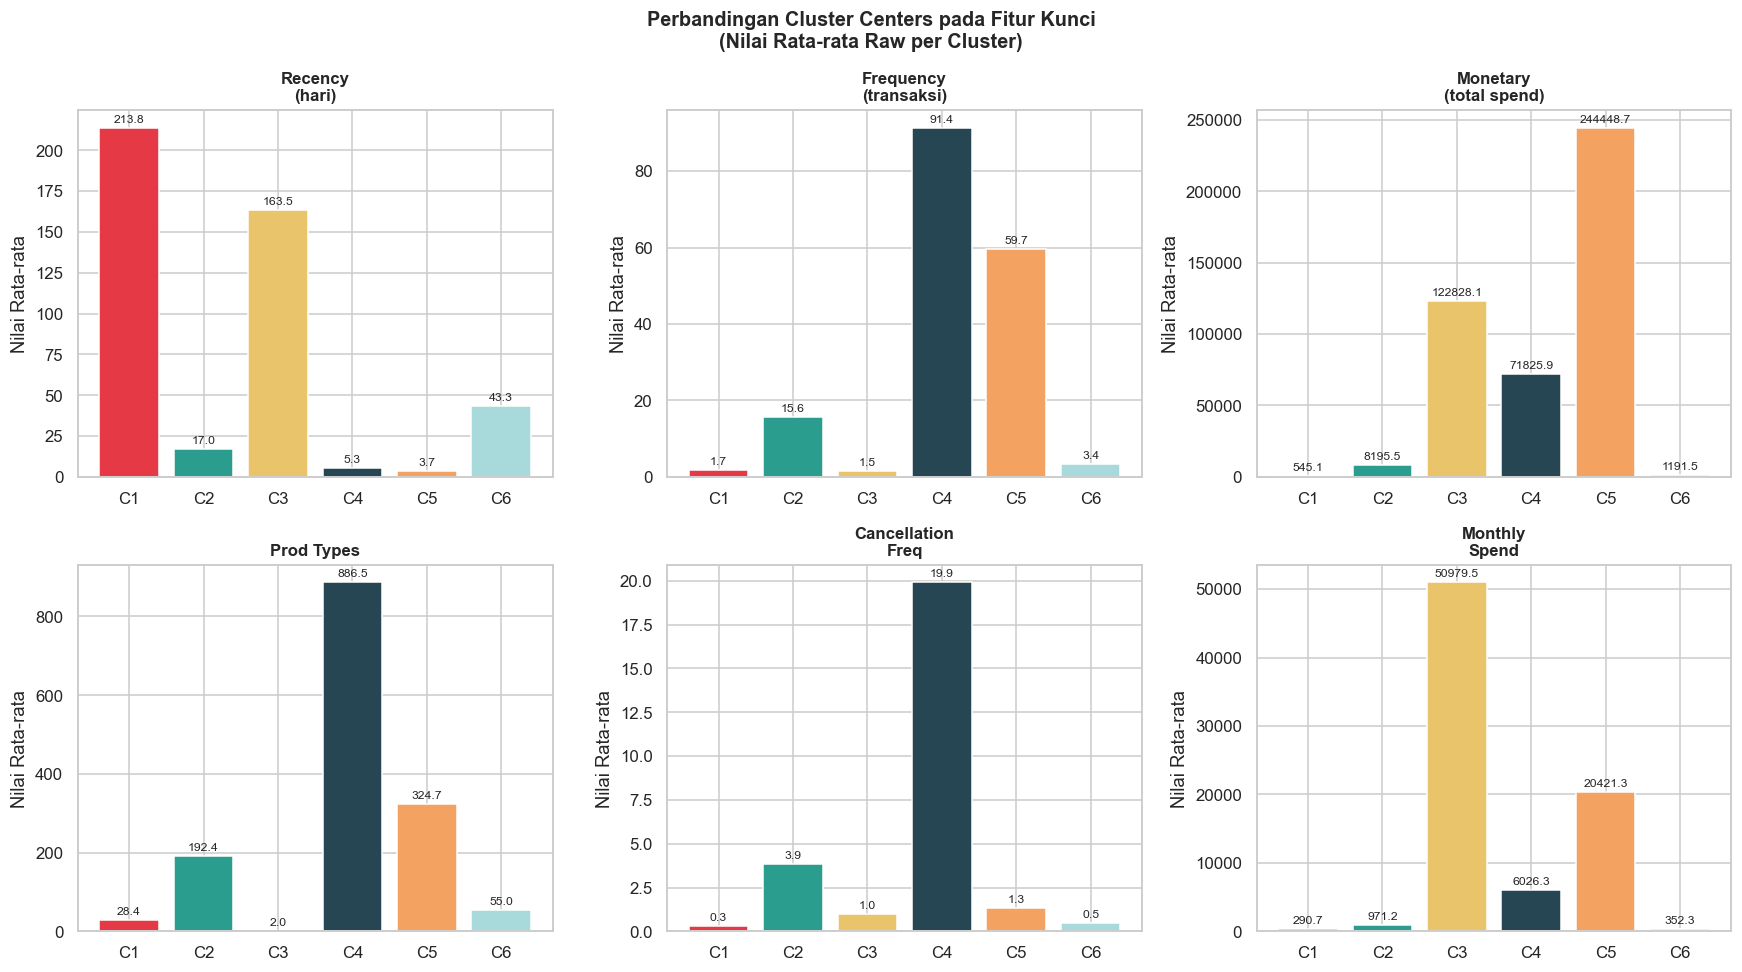

In [15]:
# ============================================================
# Visualisasi 6: Bar Chart Perbandingan Cluster Centers (Raw)
# ============================================================
centers_raw_plot = df_raw.groupby('Cluster')[feature_cols].mean()
centers_raw_plot.index = [f'Cluster {i+1}' for i in centers_raw_plot.index]

# Pilih fitur paling informatif untuk perbandingan
key_features = ['Var1', 'Var2', 'Var4', 'Var6', 'Var10', 'Var11']
key_labels   = ['Recency\n(hari)', 'Frequency\n(transaksi)', 'Monetary\n(total spend)',
                'Prod Types', 'Cancellation\nFreq', 'Monthly\nSpend']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Perbandingan Cluster Centers pada Fitur Kunci\n'
             '(Nilai Rata-rata Raw per Cluster)',
             fontsize=13, fontweight='bold')

for ax, feat, label in zip(axes.flatten(), key_features, key_labels):
    vals = centers_raw_plot[feat].values
    bars = ax.bar(
        [f'C{i+1}' for i in range(K_OPTIMAL)],
        vals,
        color=CLUSTER_COLORS,
        edgecolor='white', linewidth=1
    )
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('Nilai Rata-rata')
    
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals) * 0.01,
                f'{v:.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../models/cluster_features_comparison_pso.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Simpan Hasil Clustering

In [16]:
# Dataset berlabel
df_labeled = df_raw.copy()
df_labeled['Cluster_kmeans_pso'] = labels

# Tambahkan Label Bisnis
df_labeled['Label_Bisnis'] = df_labeled['Cluster_kmeans_pso'].map({
    0: 'HIGH-VALUE (VIP)',
    1: 'PRICE-SENSITIVE',
    2: 'HIGH-EXPECTATION (UK)',
    3: 'UNCERTAIN BUYER',
    4: 'CAUTIOUS CONSUMER',
    5: 'BALANCED CUSTOMER'
})

df_labeled.to_csv('../data/Labeled/hasildata_kmeans-pso.csv')
print('File berhasil disimpan: ../data/Labeled/hasildata_kmeans-pso.csv')


File berhasil disimpan: ../data/Labeled/hasildata_kmeans-pso.csv


**Referensi Algoritma (PSO / Swarm Intelligence):**
* Mukhamediev, R. I., et al. (2022). *Review of Artificial Intelligence and Machine Learning Technologies: Classification, Restrictions, Opportunities and Challenges*. Mathematics, 10(15), 2552. (Terdapat pada `references/mathematics-10-02552-v2.pdf`)
